# Computer Prices — 딥러닝 회귀 실습

**데이터**: `pandas/data/computer_prices_all.csv` (100,000건)
**목표**: 컴퓨터 가격(`price`) 예측 — **회귀(Regression)**

## 학습 흐름
1. 데이터 탐색적 분석 (EDA)
2. 시각화 분석
3. 데이터 전처리
4. 데이터 분할 & 스케일링
5. Baseline 딥러닝 모델
6. 모델 평가
7. 모델 개선
8. 개선 결과 비교
9. sklearn 모델과 비교

## 컬럼 설명

| 그룹 | 컬럼 | 설명 |
|------|------|------|
| 기본 | device_type | Desktop / Laptop |
| | brand | 제조사 (Samsung, Dell 등 10개) |
| | model | 모델명 (고유값 ~99K, 제거 대상) |
| | release_year | 출시 연도 |
| | os | 운영체제 (Windows, macOS, Linux, ChromeOS) |
| | form_factor | 폼팩터 (ATX, Gaming, Ultrabook 등 10개) |
| CPU | cpu_brand | CPU 제조사 (Intel, AMD, Apple) |
| | cpu_model | CPU 모델명 (고유값 ~27K, 제거 대상) |
| | cpu_tier | CPU 등급 (1~5) |
| | cpu_cores / cpu_threads | 코어 수 / 스레드 수 |
| | cpu_base_ghz / cpu_boost_ghz | 기본/부스트 클럭 |
| GPU | gpu_brand | GPU 제조사 |
| | gpu_model | GPU 모델명 (49종) |
| | gpu_tier | GPU 등급 (1~5) |
| | vram_gb | 비디오 메모리 |
| 메모리/저장 | ram_gb | RAM 용량 |
| | storage_type | 저장장치 타입 (NVMe, SSD, HDD, Hybrid) |
| | storage_gb | 저장 용량 |
| | storage_drive_count | 드라이브 수 |
| 디스플레이 | display_type | 패널 종류 (OLED, IPS, LED 등) |
| | display_size_in | 화면 크기 (인치) |
| | resolution | 해상도 |
| | refresh_hz | 주사율 |
| 전원 | battery_wh | 배터리 (Laptop만, Desktop=0) |
| | charger_watts | 충전기 와트수 (Laptop만) |
| | psu_watts | 파워서플라이 (Desktop만) |
| 기타 | wifi / bluetooth | 무선 규격 |
| | weight_kg | 무게 |
| | warranty_months | 보증 기간 |
| **타겟** | **price** | **가격 (USD)** |

## 1. 데이터 탐색적 분석 (EDA)

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

df = pd.read_csv('pandas/data/computer_prices_all.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 33)


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  object 
 14  gpu_model            100000 non-null  object 
 15  gpu_tier          

In [28]:
df.describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.591322,3.531310,2.991350,6.152180,39.706400,903.936000,1.524980,20.126655,98.464860,41.813470,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,0.336435,0.350024,1.459643,3.964926,31.902684,774.243654,0.797284,6.709577,43.301652,35.868841,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,2.000000,2.800000,1.000000,0.000000,8.000000,256.000000,1.000000,13.300000,60.000000,0.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.400000,3.300000,2.000000,4.000000,16.000000,512.000000,1.000000,14.000000,60.000000,0.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,2.600000,3.500000,3.000000,6.000000,32.000000,512.000000,1.000000,16.000000,90.000000,56.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,2.800000,3.800000,4.000000,8.000000,64.000000,1024.000000,2.000000,27.000000,120.000000,70.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,3.400000,4.500000,6.000000,16.000000,144.000000,4096.000000,4.000000,34.000000,240.000000,99.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [29]:
# 결측치 확인
print('=== 결측치 ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else '결측치 없음')

print('\n=== 범주형 컬럼 고유값 수 ===')
for col in df.select_dtypes('object').columns:
  print(f'  {col:20s}: {df[col].nunique():>6d}개')

=== 결측치 ===
결측치 없음

=== 범주형 컬럼 고유값 수 ===
  device_type         :      2개
  brand               :     10개
  model               :  99036개
  os                  :      4개
  form_factor         :     10개
  cpu_brand           :      3개
  cpu_model           :  26971개
  gpu_brand           :      4개
  gpu_model           :     49개
  storage_type        :      4개
  display_type        :      6개
  resolution          :      6개
  wifi                :      4개


In [30]:
# 타겟 분포
print('=== price 통계 ===')
print(df['price'].describe())
print(f'\n왜도(skewness): {df["price"].skew():.4f}')
print(f'첨도(kurtosis):  {df["price"].kurtosis():.4f}')

=== price 통계 ===
count    100000.000000
mean       1928.764220
std         580.492689
min         372.990000
25%        1503.990000
50%        1863.990000
75%        2287.990000
max       10984.990000
Name: price, dtype: float64

왜도(skewness): 0.9866
첨도(kurtosis):  4.8914


## 2. 시각화 분석

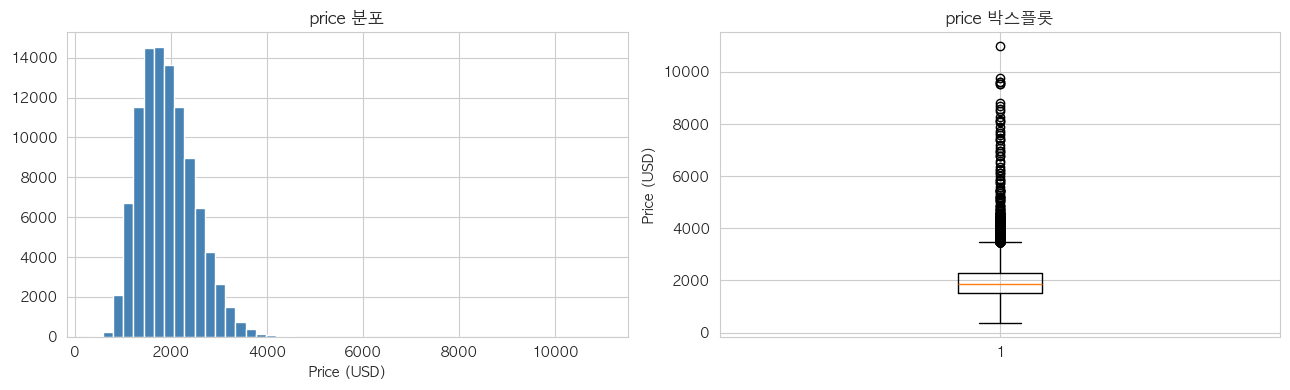

→ 우측 꼬리가 길고 고가 이상치 존재


In [31]:
# 1) 타겟(price) 분포
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('price 분포')
axes[0].set_xlabel('Price (USD)')

axes[1].boxplot(df['price'], vert=True)
axes[1].set_title('price 박스플롯')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()
print('→ 우측 꼬리가 길고 고가 이상치 존재')

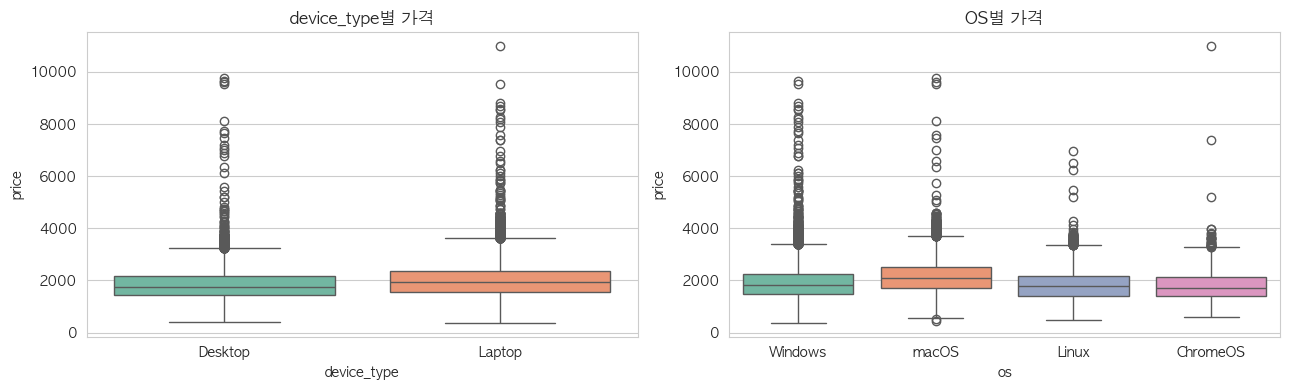

In [32]:
# 2) device_type별 가격
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df, x='device_type', y='price', ax=axes[0], palette='Set2')
axes[0].set_title('device_type별 가격')

sns.boxplot(data=df, x='os', y='price', ax=axes[1], palette='Set2')
axes[1].set_title('OS별 가격')

plt.tight_layout()
plt.show()

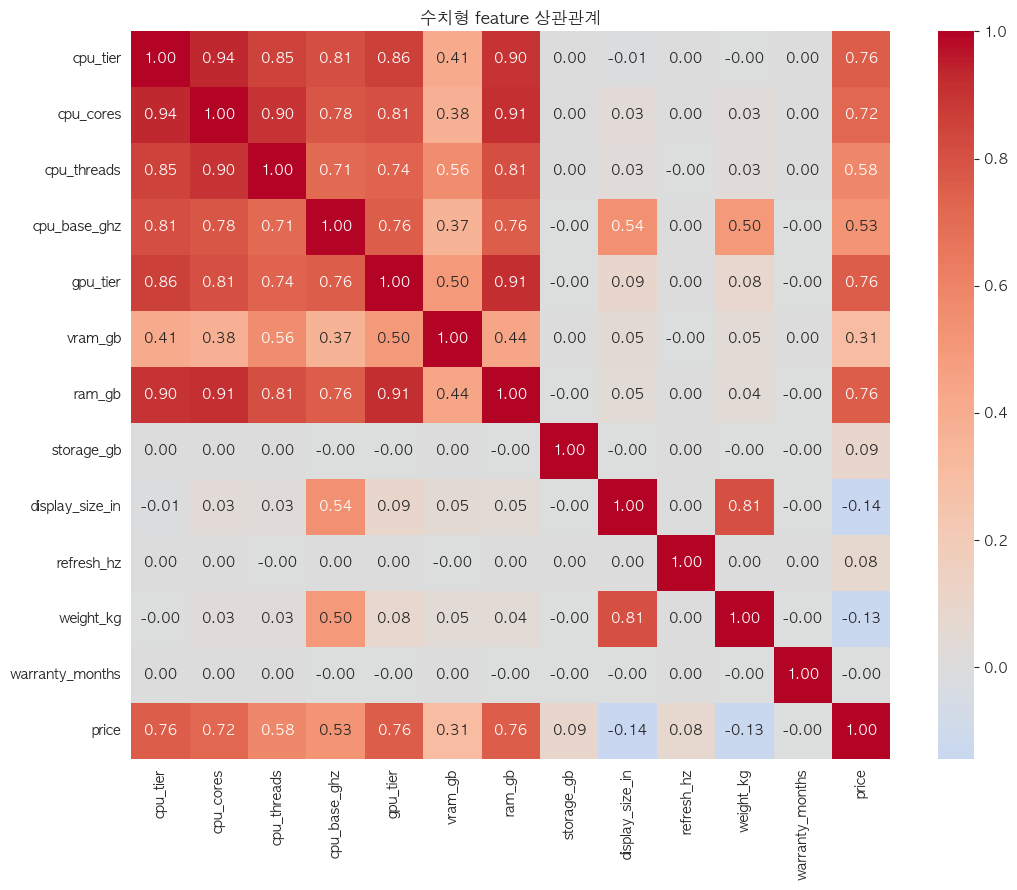

→ gpu_tier, vram_gb, ram_gb, cpu_tier 순으로 price와 상관관계 높음


In [33]:
# 3) 주요 수치형 feature와 price 상관관계
num_cols = ['cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz',
            'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb',
            'display_size_in', 'refresh_hz', 'weight_kg',
            'warranty_months', 'price']

plt.figure(figsize=(11, 9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('수치형 feature 상관관계')
plt.tight_layout()
plt.show()
print('→ gpu_tier, vram_gb, ram_gb, cpu_tier 순으로 price와 상관관계 높음')

In [ ]:
# 4) 상위 상관 feature — regplot (산점도 + 회귀선)
top_features = ['gpu_tier', 'vram_gb', 'ram_gb', 'cpu_tier']

# 10만건 전체를 그리면 느리므로 5000건 샘플링
df_sample = df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, top_features):
  sns.regplot(data=df_sample, x=col, y='price', ax=ax,
              scatter_kws={'alpha': 0.15, 's': 5},
              line_kws={'color': 'red', 'lw': 1.5})
  ax.set_title(f'{col} vs price')

plt.tight_layout()
plt.show()
print('→ 빨간 선 = 회귀선(추세선). 기울기가 클수록 price와 상관관계 높음')

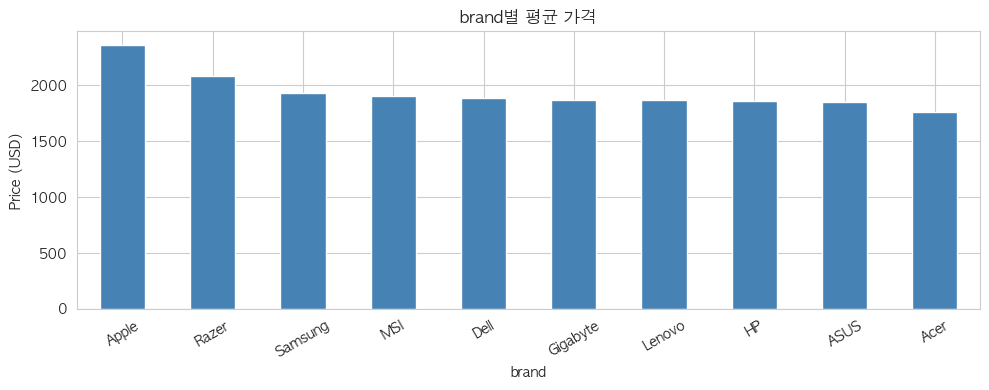

In [35]:
# 5) brand별 평균 가격
brand_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
brand_price.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('brand별 평균 가격')
plt.ylabel('Price (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. 데이터 전처리

### 처리 내용
- **제거**: `model`, `cpu_model` — 고유값이 너무 많아 인코딩 불가 (각각 ~99K, ~27K)
- **인코딩**: 나머지 범주형 → `get_dummies` (One-Hot)

In [36]:
# 고유값 과다 컬럼 제거
df_p = df.drop(columns=['model', 'cpu_model'])

# 범주형 One-Hot 인코딩
df_p = pd.get_dummies(df_p, drop_first=True)

# bool → int 변환 (TensorFlow 호환)
bool_cols = df_p.select_dtypes('bool').columns
df_p[bool_cols] = df_p[bool_cols].astype(int)

print(f'전처리 후 shape: {df_p.shape}')
df_p.head()

전처리 후 shape: (100000, 111)


,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,...,display_type_QLED,display_type_VA,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160,wifi_Wi-Fi 6,wifi_Wi-Fi 6E,wifi_Wi-Fi 7
0,2022,3,12,24,2.8,3.8,2,6,16,1024,...,0,0,1,0,0,0,0,1,0,0
1,2022,4,12,24,2.6,3.6,4,10,64,512,...,0,0,0,0,0,0,0,1,0,0
2,2024,2,8,16,2.6,3.6,1,4,8,512,...,0,0,0,0,0,1,0,1,0,0
3,2024,2,6,12,2.6,3.6,2,6,16,512,...,0,0,0,0,0,1,0,1,0,0
4,2024,5,16,32,2.8,3.9,5,12,96,256,...,0,0,0,1,0,0,0,1,0,0


## 4. 데이터 분할 & 스케일링

### 회귀에서 y 스케일링이 필요한 이유
DL은 loss(MSE)를 미분하여 gradient를 계산합니다.
y가 수백~수천 단위면 gradient가 폭발하여 학습이 불안정해집니다.

여기서는 **X와 y 모두 StandardScaler**로 스케일링하고,
평가 시 `y_scaler.inverse_transform()`으로 원래 스케일을 복원합니다.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_p.drop('price', axis=1)
y = df_p['price']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

# X 스케일링
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

# y 스케일링 (gradient 폭발 방지)
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_s = y_scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print(f'X_train: {X_train_s.shape}, X_test: {X_test_s.shape}')
print(f'y_train_s range: [{y_train_s.min():.2f}, {y_train_s.max():.2f}]')
print(f'y_test   range:  [{y_test.min():.2f}, {y_test.max():.2f}]')

X_train: (80000, 110), X_test: (20000, 110)
y_train_s range: [-2.67, 15.56]
y_test   range:  [479.99, 8579.99]


## 5. Baseline 딥러닝 모델
- 구조: Dense 64 → 32 → 1(linear)
- loss: `mse` (scaled y space에서 계산)
- 예측 후 `y_scaler.inverse_transform()`으로 원래 스케일 복원

In [38]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

tf.random.set_seed(42)
np.random.seed(42)

input_dim = X_train_s.shape[1]

baseline = Sequential([
  layers.Dense(64, activation='relu', input_shape=(input_dim,)),
  layers.Dense(32, activation='relu'),
  layers.Dense(1)
])

baseline.compile(
  optimizer='adam',
  loss='mse',
  metrics=['mae']
)
baseline.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 64)                7104      
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 9217 (36.00 KB)
Trainable params: 9217 (36.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
history_base = baseline.fit(
  X_train_s, y_train_s,
  validation_split=0.2,
  epochs=100,
  batch_size=256,
  verbose=0
)
print(f'학습 완료 (epoch={len(history_base.history["loss"])})')

학습 완료 (epoch=100)


## 6. 모델 평가 (Baseline)
- 예측값은 scaled space → `y_scaler.inverse_transform()`으로 원래 가격 복원 후 평가
- 지표: MAE, RMSE, R², MAPE

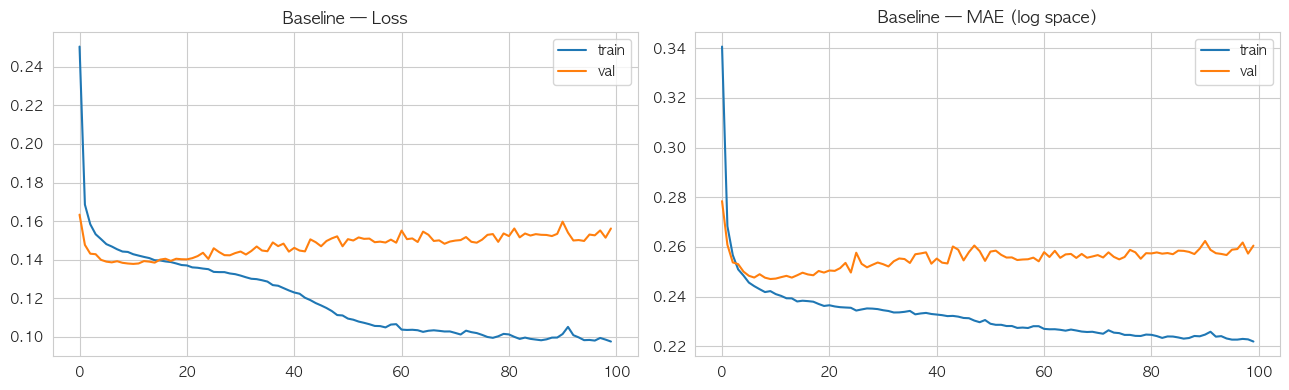

In [40]:
# 학습 곡선
def plot_history(history, title='Learning Curve'):
  fig, axes = plt.subplots(1, 2, figsize=(13, 4))
  axes[0].plot(history.history['loss'], label='train')
  axes[0].plot(history.history['val_loss'], label='val')
  axes[0].set_title(f'{title} — Loss')
  axes[0].legend()
  axes[1].plot(history.history['mae'], label='train')
  axes[1].plot(history.history['val_mae'], label='val')
  axes[1].set_title(f'{title} — MAE (log space)')
  axes[1].legend()
  plt.tight_layout()
  plt.show()

plot_history(history_base, 'Baseline')

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}

def evaluate_reg(name, model, X_s, y_true):
  """scaled 예측 → inverse_transform → 원래 스케일에서 평가"""
  y_pred_s = model.predict(X_s, verbose=0).flatten()
  y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
  results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE(%)': mape}
  print(f'=== [{name}] ===')
  print(f'  MAE:     {mae:,.2f} USD')
  print(f'  RMSE:    {rmse:,.2f} USD')
  print(f'  R²:      {r2:.4f}')
  print(f'  MAPE:    {mape:.2f}%')
  return y_pred

y_pred_base = evaluate_reg('Baseline', baseline, X_test_s, y_test)

=== [Baseline] ===
  MAE:     151.51 USD
  RMSE:    217.55 USD
  R²:      0.8567
  MAPE:    8.00%


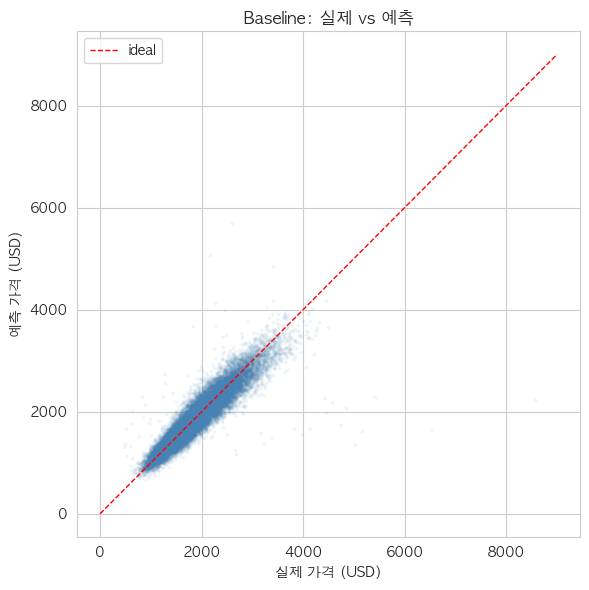

In [42]:
# 실제 vs 예측 산점도
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_base, alpha=0.05, s=3, color='steelblue')
lim = [0, y_test.max() * 1.05]
plt.plot(lim, lim, 'r--', lw=1, label='ideal')
plt.xlabel('실제 가격 (USD)')
plt.ylabel('예측 가격 (USD)')
plt.title('Baseline: 실제 vs 예측')
plt.legend()
plt.tight_layout()
plt.show()

## 7. 모델 개선

### 개선 포인트
| 항목 | Baseline | Improved |
|------|---------|----------|
| 구조 | 64 → 32 | **128 → 64 → 32** (데이터 10만건이므로 용량 확대 가능) |
| BatchNormalization | 없음 | **추가** |
| Dropout | 없음 | **0.2** |
| Learning rate | 1e-3 | 1e-3 + **ReduceLROnPlateau** |
| EarlyStopping | 없음 | **patience=15** |
| batch_size | 256 | **512** (대용량 데이터에 적합) |

### 왜 모델을 키워도 되는가
이전 Pima 실습에서는 샘플 768개에 모델을 키우면 과적합이 발생했습니다.
하지만 이 데이터는 **10만 건**이므로 모델 용량을 키워도 충분히 일반화가 가능합니다.
**샘플 수 대비 파라미터 수**가 과적합의 핵심 기준입니다.

### Dropout — 뉴런을 랜덤으로 끄는 기법

#### 무엇인가
매 학습 step마다 **뉴런의 일정 비율을 랜덤으로 비활성화**(출력을 0으로)합니다.
```
layers.Dropout(0.2)  # 매 step마다 뉴런의 20%를 랜덤으로 끔
```

#### 왜 필요한가
DL은 파라미터가 많아서 훈련 데이터를 **통째로 암기**(과적합)하기 쉽습니다.
특정 뉴런에 의존하지 못하게 랜덤으로 꺼버리면, 모델이 **여러 경로로 일반적인 패턴**을 배우게 됩니다.

#### 직관적 비유
시험 공부를 할 때 **특정 문제 답만 외우면** 조금만 바뀌어도 못 풂 (과적합)
→ 매번 노트의 **랜덤 20% 페이지를 가리고** 공부하면 핵심 원리를 이해하게 됨 (일반화)

#### 주의사항
- **학습(fit) 시에만 동작**, 예측(predict) 시에는 모든 뉴런 활성화
- 비율이 너무 높으면(0.5+) → 정보 손실 → 과소적합
- 일반적으로 **0.2 ~ 0.3** 사용

---

### BatchNormalization — 층 사이 값을 정규화

#### 무엇인가
각 층의 출력값을 **평균=0, 분산=1로 정규화**합니다.
입력 데이터에 StandardScaler를 적용하는 것처럼, **층과 층 사이**에도 같은 작업을 하는 것입니다.
```
layers.Dense(128)
layers.BatchNormalization()  # ← Dense 출력을 정규화
layers.Activation('relu')   # ← 정규화된 값에 활성화 적용
```

#### 왜 필요한가
학습이 진행되면서 각 층의 출력 분포가 **계속 변합니다** (Internal Covariate Shift).
앞 층의 가중치가 바뀌면 → 뒷 층 입력 분포가 바뀜 → 뒷 층이 계속 새로운 분포에 적응해야 함 → 학습 불안정

BatchNorm이 매 step마다 분포를 고정시켜주므로:
- **학습 속도 ↑** (gradient가 안정적)
- **더 높은 learning rate 사용 가능**
- 약한 규제 효과 (Dropout과 유사)

#### 직관적 비유
여러 사람이 **릴레이로 요리**하는 상황:
- BatchNorm 없이 = 앞 사람이 소금을 얼마나 넣었는지 몰라서 매번 맛을 다시 봐야 함
- BatchNorm 적용 = 매 단계마다 **간을 표준으로 맞춰서** 다음 사람에게 넘김 → 일관된 조리 가능

#### 배치 순서
```
Dense → BatchNormalization → Activation → Dropout
```
이 순서가 가장 일반적입니다.
Dense의 raw 출력 → 정규화 → 활성화 → 일부 뉴런 비활성화

---

### Dropout vs BatchNormalization 비교

| | Dropout | BatchNormalization |
|---|---|---|
| 목적 | **과적합 방지** (규제) | **학습 안정화** |
| 방법 | 뉴런을 랜덤으로 끔 | 출력값을 정규화 |
| 예측 시 | 모든 뉴런 활성화 | 학습 시 통계 사용 |
| 데이터 적을 때 | 효과적 | 배치가 작으면 오히려 불안정 |
| 데이터 많을 때 | 효과 약함 | **매우 효과적** |
| 함께 사용 | 가능 (Dense 뒤에 둘 다 적용) | |

### 시험에서는 이렇게 나온다
- "Dropout(0.3)이 하는 역할은?" → 매 학습 step마다 뉴런의 30%를 랜덤 비활성화하여 과적합 방지
- "BatchNormalization은 어디에 위치하는가?" → Dense와 Activation 사이
- "Dropout은 예측 시에도 동작하는가?" → **아니오**, 학습 시에만 동작

### ReduceLROnPlateau — 학습률 자동 감소

#### 무엇인가
검증 손실(val_loss)이 **일정 epoch 동안 개선되지 않으면** learning rate를 자동으로 낮추는 callback입니다.

```python
callbacks.ReduceLROnPlateau(
  monitor='val_loss',   # 감시할 지표
  factor=0.5,           # lr을 얼마나 줄일지 (새 lr = 현재 lr × factor)
  patience=5,           # 몇 epoch 동안 개선 없으면 줄일지
  min_lr=1e-5           # lr의 최소 하한선
)
```

#### 매개변수 상세 설명

| 매개변수 | 기본값 | 설명 |
|---------|--------|------|
| `monitor` | `'val_loss'` | 감시할 지표. 보통 `'val_loss'` 사용 |
| `factor` | `0.1` | 감소 비율. `0.5`면 lr이 **절반**으로 줄어듦 |
| `patience` | `10` | 이 epoch 수 동안 개선 없으면 lr 감소 |
| `min_lr` | `0` | lr의 최소값. 이보다 더 낮아지지 않음 |
| `mode` | `'auto'` | `'min'`=지표가 줄어야 개선, `'max'`=늘어야 개선 |
| `min_delta` | `1e-4` | 이 값 이상 변해야 "개선"으로 인정 |
| `cooldown` | `0` | lr 감소 후 몇 epoch 쉴지 (바로 또 줄이지 않게) |

#### 왜 필요한가
학습 초기에는 큰 lr로 빠르게 최적값 근처에 도달하고,
후반에는 작은 lr로 **세밀하게 조정**해야 합니다.

이걸 수동으로 하기 어려우니, **자동으로 "정체 감지 → lr 감소"** 해주는 것입니다.

#### 동작 흐름 예시
```
epoch  1~20: lr=0.001  → val_loss 빠르게 하락 ✓
epoch 21~25: lr=0.001  → val_loss 정체 (5 epoch 개선 없음)
          → patience=5 초과 → lr = 0.001 × 0.5 = 0.0005
epoch 26~35: lr=0.0005 → val_loss 다시 하락 ✓
epoch 36~40: lr=0.0005 → val_loss 정체
          → lr = 0.0005 × 0.5 = 0.00025
          ...
lr이 min_lr(1e-5)에 도달하면 더 이상 줄이지 않음
```

#### 직관적 비유
산에서 **가장 낮은 골짜기**를 찾아 내려가는 상황:
- 처음에는 **큰 보폭**으로 빠르게 내려감 (lr=0.001)
- 골짜기 근처에서 큰 보폭이면 **왔다 갔다 진동** → 정확한 바닥 못 찾음
- 정체 감지 → **보폭을 절반으로** → 더 정밀하게 바닥 탐색

#### EarlyStopping과 함께 쓰는 이유
```python
ReduceLROnPlateau(patience=5)   # 5 epoch 정체 → lr 줄여서 재시도
EarlyStopping(patience=15)      # 15 epoch 정체 → lr 줄여도 안 되면 학습 종료
```
ReduceLR의 patience < EarlyStopping의 patience 여야
lr 감소를 **먼저** 시도하고, 그래도 안 되면 중단하는 2단계 전략이 됩니다.

### 시험에서는 이렇게 나온다
- "ReduceLROnPlateau의 factor=0.5는 무엇을 의미하는가?" → 학습률을 현재의 50%로 줄임
- "patience=5, EarlyStopping patience=15일 때 동작 순서는?" → 5 epoch 정체시 lr↓ → 15 epoch 정체시 학습 종료
- "min_lr의 역할은?" → 학습률이 너무 작아지면 학습이 사실상 멈추므로 하한선을 설정

In [43]:
from tensorflow.keras import callbacks, optimizers

tf.random.set_seed(42)
np.random.seed(42)

improved = Sequential([
  layers.Dense(128, input_shape=(input_dim,)),
  layers.BatchNormalization(),
  layers.Activation('relu'),
  layers.Dropout(0.2),

  layers.Dense(64),
  layers.BatchNormalization(),
  layers.Activation('relu'),
  layers.Dropout(0.2),

  layers.Dense(32, activation='relu'),
  layers.Dense(1)
])

improved.compile(
  optimizer=optimizers.Adam(learning_rate=1e-3),
  loss='mse',
  metrics=['mae']
)
improved.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 128)               14208     
                                                                 
 batch_normalization_2 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 activation_2 (Activation)   (None, 128)               0         
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_3 (Bat  (None, 64)                256       
 chNormalization)                                     

In [44]:
early_stop = callbacks.EarlyStopping(
  monitor='val_loss', patience=15, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
  monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5
)

history_imp = improved.fit(
  X_train_s, y_train_s,
  validation_split=0.2,
  epochs=200,
  batch_size=512,
  callbacks=[early_stop, reduce_lr],
  verbose=0
)
print(f'학습 완료 (epoch={len(history_imp.history["loss"])})')

학습 완료 (epoch=22)


## 8. 개선 결과 비교

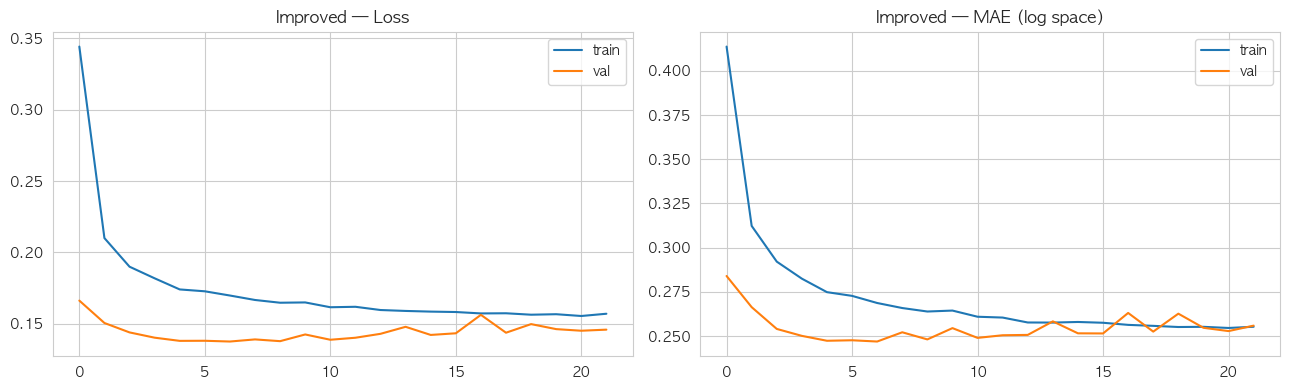

In [45]:
plot_history(history_imp, 'Improved')

In [46]:
y_pred_imp = evaluate_reg('Improved', improved, X_test_s, y_test)

=== [Improved] ===
  MAE:     142.69 USD
  RMSE:    202.48 USD
  R²:      0.8758
  MAPE:    7.67%


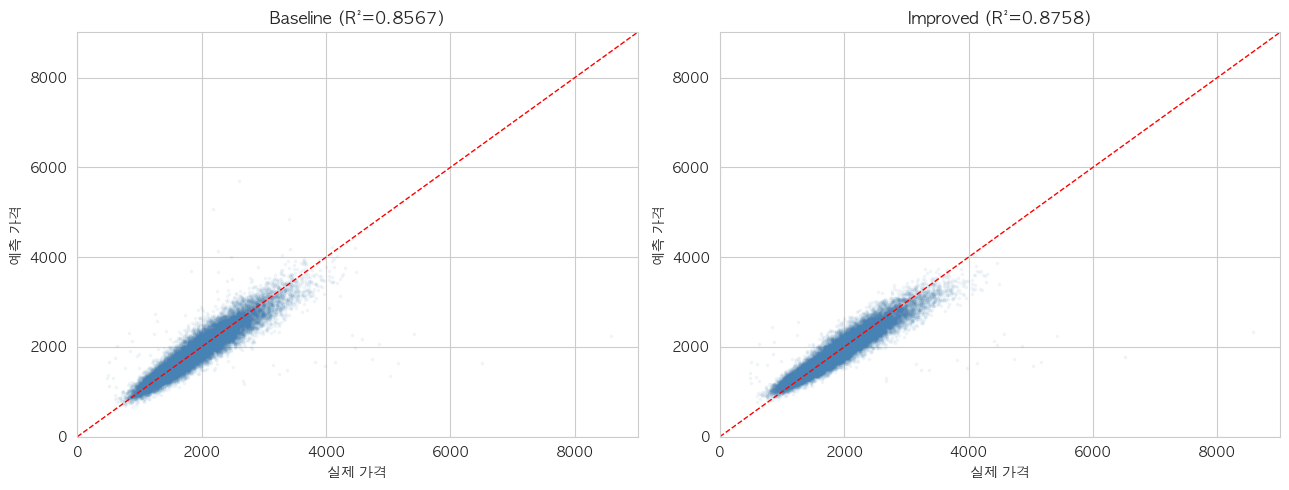

In [47]:
# 두 모델 산점도 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = [0, y_test.max() * 1.05]

for ax, name, y_pred in zip(axes, ['Baseline', 'Improved'],
                             [y_pred_base, y_pred_imp]):
  ax.scatter(y_test, y_pred, alpha=0.05, s=3, color='steelblue')
  ax.plot(lim, lim, 'r--', lw=1)
  ax.set_xlabel('실제 가격')
  ax.set_ylabel('예측 가격')
  r2 = r2_score(y_test, y_pred)
  ax.set_title(f'{name} (R²={r2:.4f})')
  ax.set_xlim(lim)
  ax.set_ylim(lim)

plt.tight_layout()
plt.show()

=== DL 모델 비교 ===
               MAE      RMSE      R²  MAPE(%)
Baseline  151.5058  217.5470  0.8567    7.999
Improved  142.6897  202.4772  0.8758    7.671


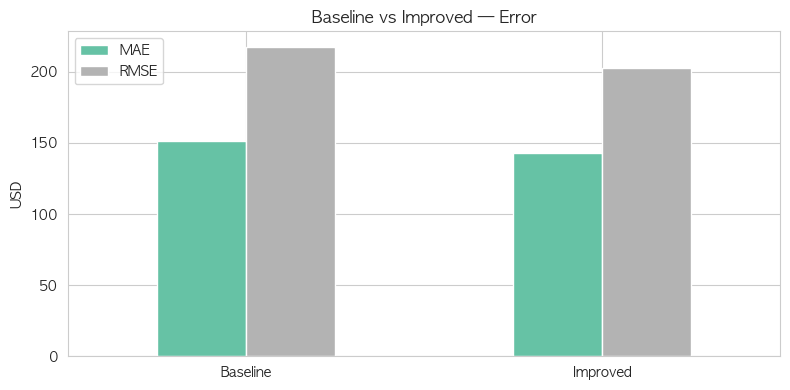

In [48]:
# 지표 비교 표
result_df = pd.DataFrame(results).T
print('=== DL 모델 비교 ===')
print(result_df.round(4))

ax = result_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(8, 4), colormap='Set2')
ax.set_title('Baseline vs Improved — Error')
ax.set_ylabel('USD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. sklearn 모델과 비교

DL과 전통 ML 모델(Ridge, RandomForest, GradientBoosting)의 성능을 비교합니다.
대용량 tabular 데이터에서는 **GradientBoosting 계열이 대체로 최고 성능**을 보입니다.

In [49]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sk_models = {
  'Ridge': Ridge(alpha=1.0),
  'RandomForest': RandomForestRegressor(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
  ),
  'GradientBoosting': GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
  ),
}

for name, m in sk_models.items():
  m.fit(X_train_s, y_train_s)
  y_pred_s = m.predict(X_test_s)
  y_pred_sk = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
  mae = mean_absolute_error(y_test, y_pred_sk)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred_sk))
  r2 = r2_score(y_test, y_pred_sk)
  mape = np.mean(np.abs((y_test - y_pred_sk) / y_test)) * 100
  results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE(%)': mape}
  print(f'[{name}] MAE={mae:,.2f}, RMSE={rmse:,.2f}, R²={r2:.4f}, MAPE={mape:.2f}%')

[Ridge] MAE=143.17, RMSE=202.85, R²=0.8754, MAPE=7.66%
[RandomForest] MAE=165.29, RMSE=231.42, R²=0.8378, MAPE=8.88%
[GradientBoosting] MAE=139.63, RMSE=200.58, R²=0.8782, MAPE=7.41%


=== 전체 모델 비교 ===
                       MAE      RMSE      R²  MAPE(%)
Baseline          151.5058  217.5470  0.8567   7.9990
Improved          142.6897  202.4772  0.8758   7.6710
Ridge             143.1656  202.8451  0.8754   7.6613
RandomForest      165.2854  231.4188  0.8378   8.8820
GradientBoosting  139.6281  200.5837  0.8782   7.4110


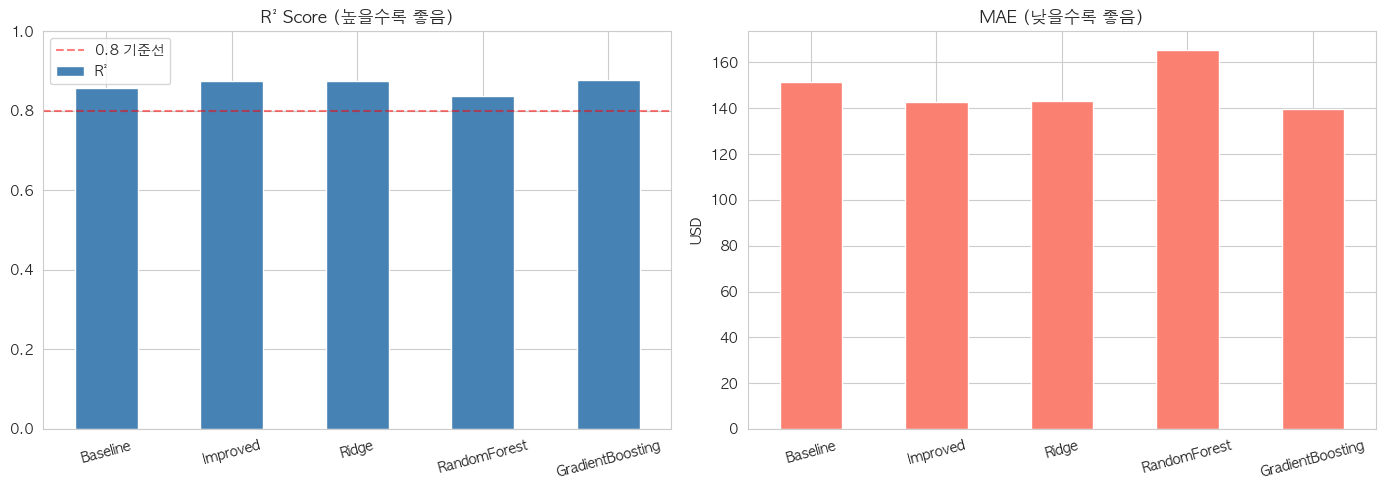

In [50]:
# 전체 모델 비교 표 + 시각화
result_df = pd.DataFrame(results).T
print('=== 전체 모델 비교 ===')
print(result_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

result_df['R²'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('R² Score (높을수록 좋음)')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.8 기준선')
axes[0].legend()

result_df['MAE'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('MAE (낮을수록 좋음)')
axes[1].set_ylabel('USD')

for ax in axes:
  ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 정리

### Computer Prices 데이터의 핵심 포인트
- **10만 건 대용량** — DL이 충분히 학습할 수 있는 데이터 규모
- **결측치 없음** — 전처리가 비교적 간단
- `model`, `cpu_model`은 고유값 과다(~99K, ~27K) → 제거가 합리적
- 타겟(price) **우측 꼬리 분포** → StandardScaler로 정규화

### 회귀에서 y 스케일링이 필수인 이유
| | 분류 | 회귀 |
|---|---|---|
| y 값 | 라벨 0/1 (이미 작음) | 연속값 (수백~수만) |
| 출력층 | sigmoid (0~1) | linear (제한 없음) |
| Loss | BCE — 안정적 | **MSE — y² 이 gradient에 반영 → 폭발 위험** |
| 스케일링 | **불필요** | **필요** (StandardScaler 또는 log1p) |

### y 스케일링 방법 비교
| 방법 | 적용 | 복원 | 특징 |
|------|------|------|------|
| **StandardScaler** | `y_scaler.fit_transform(y)` | `y_scaler.inverse_transform()` | 범용적, 대부분의 경우 사용 |
| log1p | `np.log1p(y)` | `np.expm1()` | skewed 분포 보정에 유리 |

### DL vs ML 비교 교훈
- 데이터가 충분하면(수만 건 이상) DL도 ML과 비슷한 성능 달성 가능
- 그래도 **GradientBoosting 계열은 tabular 데이터의 왕** (NeurIPS 2022)
- DL의 강점은 tabular보다 **이미지, 텍스트, 시계열** 등 비정형 데이터

### 시험에서는 이렇게 나온다
- "회귀 모델에서 R² 값이 음수가 나왔다. 원인은?" → **y 스케일링 누락** 또는 **예측값 inverse_transform 누락**
- "예측 후 원래 스케일로 복원하는 방법은?" → `y_scaler.inverse_transform()`
- "대용량 데이터에서 batch_size를 키우는 이유는?" → 학습 속도 ↑, gradient 안정성 ↑
- "EarlyStopping의 `restore_best_weights=True`는 무엇을 하는가?" → 과적합 직전의 최적 가중치로 복원